<a href="https://colab.research.google.com/github/aksharasrivatsan/Mental-Health-Hybrid-Quantum/blob/VGGnet-implementation-and-evaluation/VGGnet_for_journal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow-datasets librosa tqdm
import tensorflow as tf
import tensorflow_datasets as tfds
import os
import numpy as np
import librosa
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from PIL import Image as PILImage
from tqdm import tqdm
from pathlib import Path

# CREMA-D Emotion Label Map
EMOTION_MAP = {
    0: "Anger",
    1: "Disgust",
    2: "Fear",
    3: "Happiness",
    4: "Neutral",
    5: "Sadness",
}

# Configuration
SR = 16000
TARGET_DURATION = 3.0
TARGET_SAMPLES = int(SR * TARGET_DURATION)
N_MFCC = 40
TARGET_RMS = 0.1
OUTPUT_DIR = "/content/mfcc_images"

# Load CREMA-D Dataset
def load_crema_d_splits():
    print("Loading CREMA-D dataset...")

    train_ds, val_ds, test_ds = tfds.load(
        "crema_d",
        split=["train", "validation", "test"],
        with_info=False
    )

    print("Loaded Train / Validation / Test splits successfully.")
    return train_ds, val_ds, test_ds

# Standardize Audio Length
def standardize_audio(audio, target_samples=TARGET_SAMPLES):
    if len(audio) > target_samples:
        audio = audio[:target_samples]
    else:
        pad = target_samples - len(audio)
        audio = np.pad(
            audio,
            (pad // 2, pad - pad // 2),
            mode="constant"
        )

    return audio

# Normalize RMS Energy
def normalize_rms(audio, target_rms=TARGET_RMS):
    rms = np.sqrt(np.mean(audio ** 2))

    if rms > 1e-6:
        audio = audio * (target_rms / rms)

    return audio

# Extract MFCC Image
def create_mfcc_image(audio):
    # Convert to float32
    audio = audio.astype(np.float32)

    # Scale if needed
    if np.max(np.abs(audio)) > 1.0:
        audio = audio / 32768.

    audio, _ = librosa.effects.trim(audio, top_db=20)

    # Standardize duration
    audio = standardize_audio(audio)

    # RMS normalization
    audio = normalize_rms(audio)

    # MFCC extraction
    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=SR,
        n_mfcc=N_MFCC,
        n_fft=512,
        hop_length=128
    )

    # Remove MFCC coefficient 0
    mfcc = mfcc[1:, :]

    # Delta features
    mfcc_delta = librosa.feature.delta(mfcc)
    mfcc_delta2 = librosa.feature.delta(mfcc, order=2)

    # Stack all features
    combined = np.vstack([mfcc, mfcc_delta, mfcc_delta2])
    combined = np.sign(combined) * np.log1p(np.abs(combined))

    # Row-wise normalization
    combined_norm = np.zeros_like(combined)

    for i in range(combined.shape[0]):
        row = combined[i]

        # Contrast stretching
        low = np.percentile(row, 5)
        high = np.percentile(row, 95)

        row = np.clip(row, low, high)

        # Normalize row
        combined_norm[i] = (
            (row - row.min()) /
            (row.max() - row.min() + 1e-9)
        )

    # Convert to grayscale image
    as_uint8 = (combined_norm * 255).astype(np.uint8)
    gray_img = PILImage.fromarray(as_uint8, mode="L")

    # Resize to CNN-friendly size
    resized_img = gray_img.resize((224, 224), PILImage.BICUBIC)

    # Convert to RGB using inferno colormap
    resized_array = np.array(resized_img) / 255.0

    cmap = plt.get_cmap("inferno")
    colored = cmap(resized_array)
    colored_rgb = (colored[:, :, :3] * 255).astype(np.uint8)

    final_img = PILImage.fromarray(colored_rgb, mode="RGB")

    return final_img

# Save Dataset Split Images
def process_split(dataset, split_name):
    split_dir = Path(OUTPUT_DIR) / split_name
    split_dir.mkdir(parents=True, exist_ok=True)

    emotion_counts = {emotion: 0 for emotion in EMOTION_MAP.values()}

    total_samples = 0

    print(f"\nProcessing {split_name} split...")

    for idx, sample in enumerate(tqdm(dataset)):
        try:
            audio = sample["audio"].numpy()
            label = int(sample["label"].numpy())

            emotion_name = EMOTION_MAP[label]
            emotion_dir = split_dir / emotion_name
            emotion_dir.mkdir(parents=True, exist_ok=True)

            # Generate MFCC image
            mfcc_img = create_mfcc_image(audio)

            # File name
            file_name = f"{split_name}_{idx:05d}.png"
            save_path = emotion_dir / file_name

            # Save image
            mfcc_img.save(save_path)

            emotion_counts[emotion_name] += 1
            total_samples += 1

        except Exception as e:
            print(f"Error processing sample {idx}: {e}")

    print(f"\nFinished {split_name} split")
    print(f"Total images saved: {total_samples}")

    print("\nClass distribution:")
    for emotion, count in emotion_counts.items():
        print(f"{emotion:12s}: {count}")

def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    train_ds, val_ds, test_ds = load_crema_d_splits()

    process_split(train_ds, "train")
    process_split(val_ds, "validation")
    process_split(test_ds, "test")

    print("\nAll MFCC images generated successfully.")
    print(f"Saved to: {OUTPUT_DIR}")


if __name__ == "__main__":
    main()

Loading CREMA-D dataset...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

...


Finished train split
Total images saved: 5144

Class distribution:
Anger       : 750
Disgust     : 879
Fear        : 879
Happiness   : 879
Neutral     : 878
Sadness     : 879

Processing validation split...


100%|██████████| 738/738 [01:21<00:00,  9.01it/s]



Finished validation split
Total images saved: 738

Class distribution:
Anger       : 108
Disgust     : 126
Fear        : 126
Happiness   : 126
Neutral     : 126
Sadness     : 126

Processing test split...


100%|██████████| 1556/1556 [02:21<00:00, 10.96it/s]


Finished test split
Total images saved: 1556

Class distribution:
Anger       : 228
Disgust     : 266
Fear        : 265
Happiness   : 266
Neutral     : 266
Sadness     : 265

All MFCC images generated successfully.
Saved to: /content/mfcc_images


In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications


IMG_SIZE = (224, 224)
BATCH_SIZE = 32
DATA_DIR = "/content/mfcc_images"


train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR + "/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR + "/validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)


base_model = applications.VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(6, activation='softmax')
])


model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Starting VGG net (Classical) model training ...")
history = model.fit(train_ds, validation_data=val_ds, epochs=20)

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()


print(f"\nFinal Training Accuracy: {acc[-1]:.4f}")
print(f"Final Validation Accuracy: {val_acc[-1]:.4f}")

model.save("vgg_baseline_model.h5")
print("Model saved")

Found 5144 files belonging to 6 classes.
Found 738 files belonging to 6 classes.
Starting VGG net (Classical) model training ...
Epoch 1/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 44s 247ms/step - accuracy: 0.1719 - loss: 9.3697 - val_accuracy: 0.1707 - val_loss: 1.7912
Epoch 2/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 38s 234ms/step - accuracy: 0.1627 - loss: 1.7920 - val_accuracy: 0.1707 - val_loss: 1.7907
Epoch 3/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 37s 231ms/step - accuracy: 0.1612 - loss: 1.8058 - val_accuracy: 0.1707 - val_loss: 1.7904
Epoch 4/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 37s 231ms/step - accuracy: 0.1602 - loss: 1.7900 - val_accuracy: 0.1707 - val_loss: 1.7903
Epoch 5/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 37s 231ms/step - accuracy: 0.1635 - loss: 1.7993 - val_accuracy: 0.1707 - val_loss: 1.7903
Epoch 6/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 37s 231ms/step - accuracy: 0.1643 - loss: 1.7897 - val_accuracy: 0.1707 - val_loss: 1.7902
Epoch 7/20
161/161 ━━━━━━━━━━━━━━━━━━━━ 37s 231ms/step - accuracy: 0.1625 - loss: 1.7


Final Training Accuracy: 0.1516
Final Validation Accuracy: 0.1707
Model saved


In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications


IMG_SIZE = (224, 224)
BATCH_SIZE = 32
DATA_DIR = "/content/mfcc_images"


train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR + "/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR + "/validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)


base_model = applications.VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(6, activation='softmax')
])


model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("Starting VGG net (Classical) model training ...")
history = model.fit(train_ds, validation_data=val_ds, epochs=50)

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)


plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()


print(f"\nFinal Training Accuracy: {acc[-1]:.4f}")
print(f"Final Validation Accuracy: {val_acc[-1]:.4f}")

model.save("vgg_baseline_model.h5")
print("Model saved")

Found 5144 files belonging to 6 classes.
Found 738 files belonging to 6 classes.
Starting VGG net (Classical) model training ...
Epoch 1/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 48s 264ms/step - accuracy: 0.1825 - loss: 8.4208 - val_accuracy: 0.2439 - val_loss: 1.6967
Epoch 2/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 74s 233ms/step - accuracy: 0.1695 - loss: 1.7946 - val_accuracy: 0.1707 - val_loss: 1.7908
Epoch 3/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 37s 228ms/step - accuracy: 0.1689 - loss: 1.7897 - val_accuracy: 0.1707 - val_loss: 1.7904
Epoch 4/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 36s 226ms/step - accuracy: 0.1654 - loss: 1.7919 - val_accuracy: 0.1734 - val_loss: 1.7870
Epoch 5/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 37s 231ms/step - accuracy: 0.1577 - loss: 1.7891 - val_accuracy: 0.1762 - val_loss: 1.7864
Epoch 6/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 37s 228ms/step - accuracy: 0.1627 - loss: 1.7920 - val_accuracy: 0.1707 - val_loss: 1.7902
Epoch 7/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 37s 231ms/step - accuracy: 0.1633 - loss: 1.7


Final Training Accuracy: 0.1559
Final Validation Accuracy: 0.1707
Model saved


In [6]:
!ls /content/mfcc_images/train/Happiness | wc -l

879


Found 5144 files belonging to 6 classes.
Found 738 files belonging to 6 classes.
Training the Rescue Baseline...
Epoch 1/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 47s 264ms/step - accuracy: 0.2957 - loss: 1.9384 - val_accuracy: 0.3523 - val_loss: 1.7134
Epoch 2/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 36s 222ms/step - accuracy: 0.3449 - loss: 1.7270 - val_accuracy: 0.3686 - val_loss: 1.5944
Epoch 3/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 37s 232ms/step - accuracy: 0.3781 - loss: 1.6254 - val_accuracy: 0.3875 - val_loss: 1.5820
Epoch 4/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 36s 226ms/step - accuracy: 0.3830 - loss: 1.5937 - val_accuracy: 0.3889 - val_loss: 1.5458
Epoch 5/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 37s 230ms/step - accuracy: 0.4053 - loss: 1.5545 - val_accuracy: 0.4255 - val_loss: 1.5415
Epoch 6/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 37s 231ms/step - accuracy: 0.4143 - loss: 1.5217 - val_accuracy: 0.4160 - val_loss: 1.4978
Epoch 7/30
161/161 ━━━━━━━━━━━━━━━━━━━━ 41s 230ms/step - accuracy: 0.4273 - loss: 1.4782 - val_accura

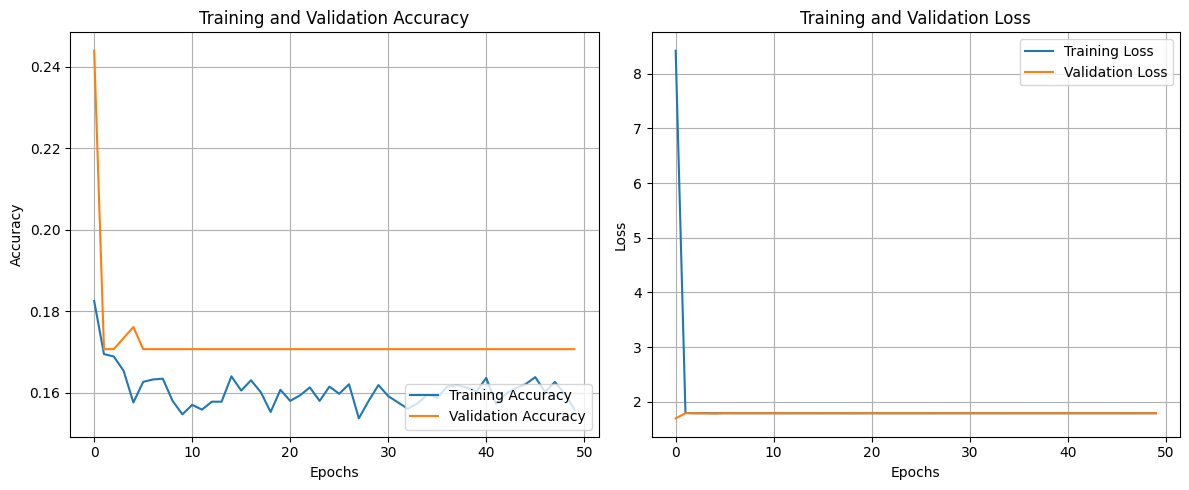

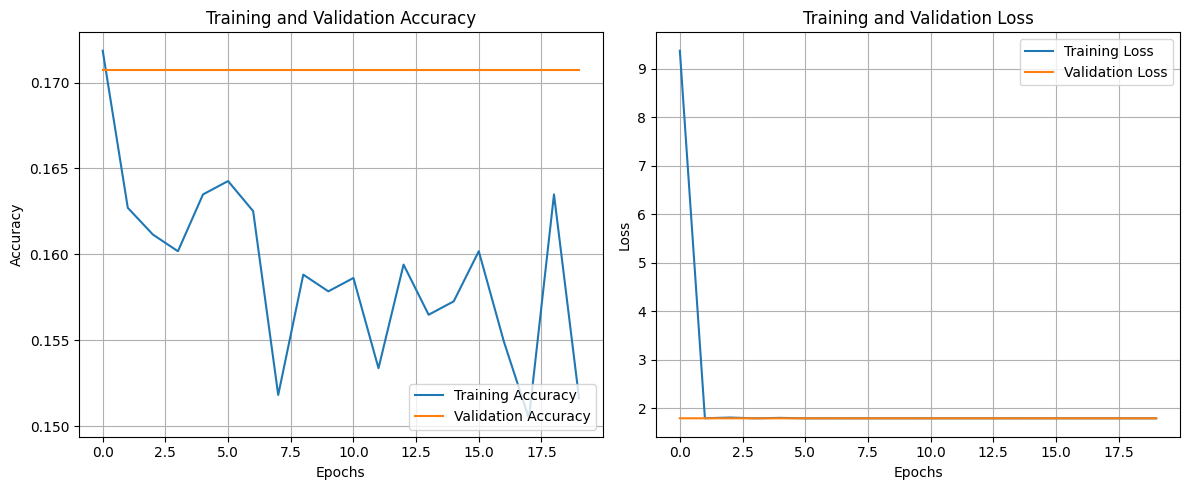

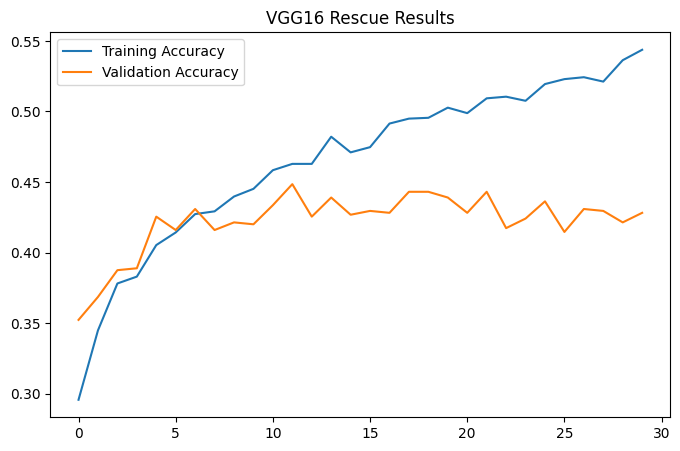

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications
import matplotlib.pyplot as plt


IMG_SIZE = (224, 224)
BATCH_SIZE = 32
DATA_DIR = "/content/mfcc_images"


train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR + "/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR + "/validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='int'
)


base_model = applications.VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(6, activation='softmax')
])


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


print("Training the Rescue Baseline...")
history = model.fit(train_ds, validation_data=val_ds, epochs=30)


%matplotlib inline
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs_range = range(len(acc))

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('VGG16 Rescue Results')
plt.legend()
plt.show()